Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ccxt

print("All libraries downloaded, lets start")

All libraries downloaded, lets start


/Users/skull13/QUANT TRAINING/Project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Pulling the Crypto Price Data

Downloading the OHLCV data:

Open - price at start of the time period

High - highest price during the period

Low - lowest price during the period

Close - price at the end of the period

Volume - how many crypto was traded, will demonstrate how active the market is

Connecting to Binance, reading public price history

Since Binance doesn't work here (US), connecting to Kraken

In [2]:
# exchange = ccxt.binance()

In [3]:
exchange = ccxt.kraken()

In [4]:
def get_crypto_data(symbol, timeframe ='1d', limit = 500):
    """
    Downloading the historical price data for crypto currency"
    Args:
        symbol (_type_): the crypto that it is for example 'BTC/USDT' means Bitcoin priced in dollars
        timeframe (str, optional): _description_. Defaults to '1d'. This means each row is equal to 1 day. '1h' would have meant 1 hour
        limit (int, optional): _description_. Defaults to 500. We downlaod a maximum of 500 candles (rows)
    """
    # Gets the raw data from Binance
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe=timeframe, limit=limit)
    
    # transforming the raw downloaded data into a dataframe
    df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    
    # since timestamp can come as a huge number
    # changing it to a more user-friendly date
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    
    # Making the date the index
    df.set_index('timestamp', inplace = True)
    
    return df

Downloading 500 days of daily Bitcoin data

In [5]:
btc = get_crypto_data('BTC/USD', timeframe='1d', limit = 500)

In [6]:
print(btc.head())

               open     high      low    close       volume
timestamp                                                  
2025-04-20  85121.3  85309.2  84007.4  85150.1   517.726683
2025-04-21  85150.0  88490.0  85150.0  87500.6  1901.274900
2025-04-22  87500.7  93888.0  87100.0  93472.0  2972.048260
2025-04-23  93472.0  94635.1  91949.5  93677.0  2009.603221
2025-04-24  93677.0  94000.0  91711.0  93999.9  1079.247341


List of coins I want to work with

A mix of large and mid cap crypto

Cap is short for market capitalization. In this case it means the total value of all coins in existence

Market Cap = Price x Total Coins in Existence

Large Caps - are the "blue chips". they have been around the longest and most people trust them, most money flows through them. Examples are BTC and ETH. Which are worth hundreds of billions of dollars.

Mid Caps - are established but smaller. They have more room to grow, but are also more riskier. Examples include Solana (SOL), Avalanche (AVAX) and Cardona (ADA). Worth Billions, not just tens of billions yet.

Note that Large caps tends to be more stable and harder to find edges in because several smart peopple are already watching them. Mid caps can have more inefficiencies and also more hidden patterns to find. 

Oh and an 'edge' is a repeatable advantage. Its something we know we can do that lets us win more than we lose, consistently over time. 

For example a normal coin flip is 50/50. There is no edge. But imagine you discovered the coin was slightly bent, and bent coins land on heads 53% of the time. That's an edge. 3% doesn't sound like much, but if you bet $100 on every flip, over thousands of flips you'd make a fortune. Casinos are literally built on edges of 2-5%.


In crypto markets, an edge sounds like:

"When Bitcoin's volume is 50% above its 7-day average AND its price went up yesterday, it goes up again the next day 57% of the time instead of the random 50%."

That extra 7% — that's your edge. You code it, you backtest it to make sure it's real and not a fluke, and then you trade it.

The moment too many people find the same edge it disappears. Since, everyone trades it away.

Before trusting an edge ask yourself this.

1. Does it make logical sense? If you found that Bitcoin goes up every time it rains in Tokyo, that's probably a coincidence. A real edge has a reason behind it — like "institutions trade during business hours so retail gets front-run at night." Logic first.
2. Does it survive transaction costs? This is where most "edges" die. You might find a pattern that makes 0.15% per trade, but if it costs you 0.20% in fees to execute, you're actually losing money. Your project specifically gives you 20 bps (0.20%) as the cost — this is a real filter.
3. Does it hold up out-of-sample? If you found a pattern by looking at 2020-2022 data, does it also work on 2023-2024 data that you didn't use to find it? If yes, it's probably real. If it only works on the exact data you used to find it, you've been fooled by randomness — quants call this overfitting, and it's the #1 mistake beginners make.

In [7]:
coins = ['BTC/USD', 'ETH/USD', 'SOL/USD', 'ADA/USD', 'AVAX/USD']

In [8]:
# data dictionary 
data = {}

Downloading data for all the cryptos and storing them in the dictionary

In [9]:
for coin in coins:
    # make the part before '/USD' our label
    name = coin.split('/')[0]
    data[name] = get_crypto_data(coin, timeframe='1d', limit=500)
    print(f"Downloaded {name} - {len(data[name])} days of data")

Downloaded BTC - 500 days of data
Downloaded ETH - 500 days of data
Downloaded SOL - 500 days of data
Downloaded ADA - 500 days of data
Downloaded AVAX - 500 days of data


Pulling all the closing prices into a table

1 column per coin and 1 row per day

Getting the 'close' column from each coin and combining all of them into a Dataframe


In [10]:
prices = pd.DataFrame({
    name: data[name]['close'] for name in data
})

print(f"Shape: {prices.shape}") # should display (500,5) since there are 500 days for 5 coins
print(prices.tail())

Shape: (500, 5)
                BTC      ETH     SOL       ADA   AVAX
timestamp                                            
2026-08-28  77841.8  2442.73  104.14  0.203180  7.307
2026-08-29  78227.8  2457.38  105.61  0.201727  7.334
2026-08-30  77681.6  2416.95  101.80  0.192926  7.122
2026-08-31  78566.1  2467.12  103.04  0.197826  7.234
2026-09-01  77434.8  2419.85  100.08  0.196421  7.222


Normalizing prices so they can be compared on the same chart

All prices are divided by the first price, so all the coins start at 1.0

In [11]:
normalized = prices / prices.iloc[0]

Plotting the graph

It will show % growth not the actual raw price

BTC at $40k and SOL at $100 aren't directly comparable

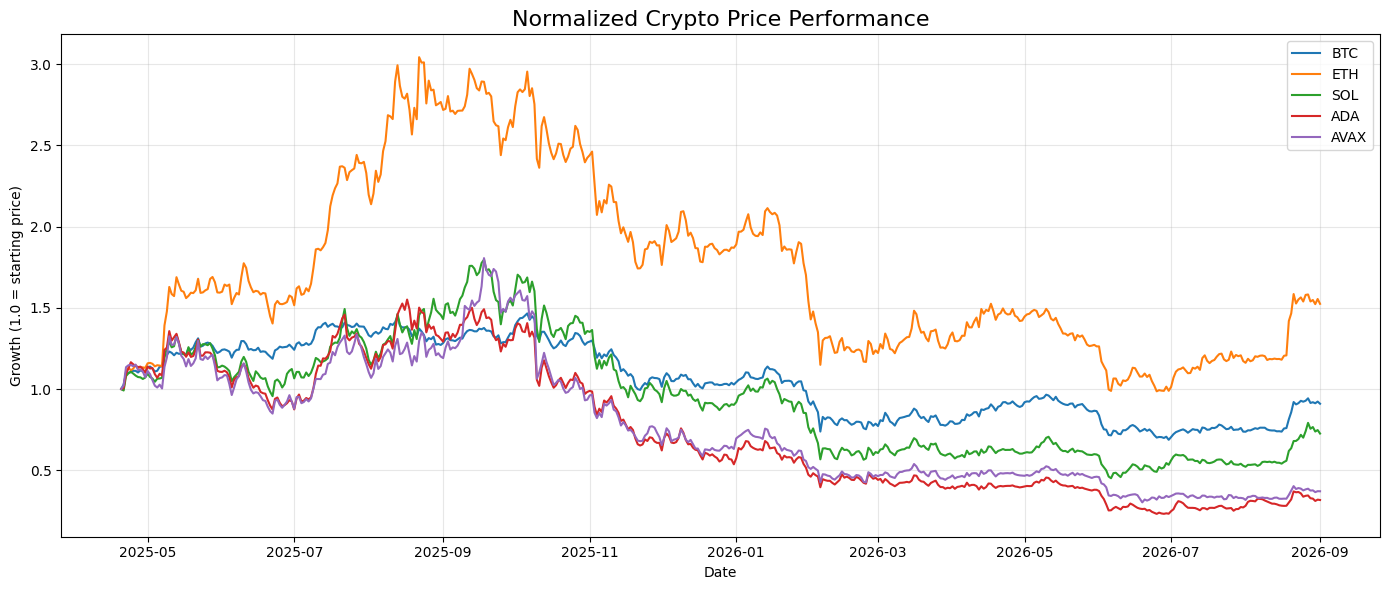

In [12]:
plt.figure(figsize=(14,6))

for coin in normalized.columns:
    plt.plot(normalized.index, normalized[coin], label=coin)
    
plt.title("Normalized Crypto Price Performance", fontsize = 16)

plt.xlabel("Date")
plt.ylabel("Growth (1.0 = starting price)")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

On the plot we can observe the correlation. How they move together. 

Observe if one coin moves first and the others follow, that can be a tradeable signal.

Bitcoin goes from $100 to $110. That's a +10% return.
Bitcoin goes from $40,000 to $44,000. That's also a +10% return.

The dollar amounts are totally different but the return is the same. Returns let us compare fairly across different coins, different time periods, and different price levels. It's like grading everything on the same scale.

Return = (Today's Price - Yesterday's Price) / Yesterday's Price

Calculating daily returns for all coins
Note that pct_change does the return calculation stated above

In [13]:
returns = prices.pct_change()

The first row should be dropped because it is NaN(Not a Number). Since there is no "yesterday" for the first day.

In [14]:
returns = returns.dropna()

Lets consider describe as our first line of analysis

mean - the average daily return. (a tiny return is normal since most days are usually smal moves)

std - is the standard deviation, used to measure the volatility. Higher std means the coin is very unstable.

min/max - this represents the worst and the best single days.

In [15]:
print(f"Returns shape: {returns.shape}")
print("\nThe first 5 rows of returns:")
print(returns.head())
print("\nBasic stats about our returns:")
print(returns.describe())

Returns shape: (499, 5)

The first 5 rows of returns:
                 BTC       ETH       SOL       ADA      AVAX
timestamp                                                   
2025-04-21  0.027604 -0.004674 -0.009066  0.006951  0.022063
2025-04-22  0.068244  0.112349  0.089439  0.087987  0.109940
2025-04-23  0.002193  0.021882  0.015788  0.027237  0.010403
2025-04-24  0.003447 -0.014504  0.008862  0.035008  0.001791
2025-04-25  0.007630  0.009384 -0.010227 -0.010755 -0.007149

Basic stats about our returns:
              BTC         ETH         SOL         ADA        AVAX
count  499.000000  499.000000  499.000000  499.000000  499.000000
mean     0.000045    0.001472    0.000008   -0.001510   -0.001167
std      0.021691    0.035755    0.036097    0.039881    0.040248
min     -0.139091   -0.148863   -0.149663   -0.196860   -0.269556
25%     -0.012118   -0.017768   -0.022869   -0.026346   -0.024753
50%     -0.000143    0.000521   -0.000884   -0.004983   -0.001659
75%      0.011458    0.01

Visualization of the Return Distribution

Histograms show how often each return size happen. It's like a bar chart of how many days did a coin return X%?

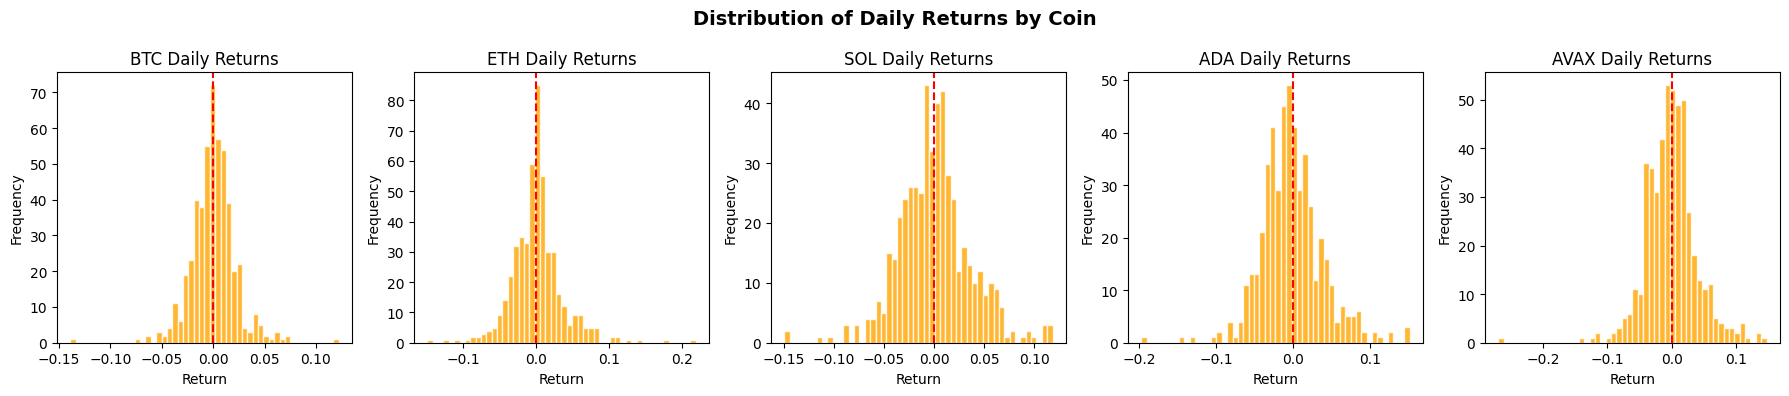

In [16]:
fig, axes = plt.subplots(1, len(returns.columns), figsize=(18,4))

for i, coin in enumerate(returns.columns):
    axes[i].hist(returns[coin], bins=50, color='orange', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{coin} Daily Returns')

    axes[i].set_xlabel('Return')
    axes[i].set_ylabel('Frequency')

    axes[i].axvline(x=0, color='red', linestyle='--', linewidth=1.5)

# These belong outside the loop. Inside it, the figure was drawn five times
# and tight_layout was missing its parentheses, so it never ran.
plt.suptitle('Distribution of Daily Returns by Coin', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The red line is 0, to the right are the positive daysm while to the left are the negative days

If the distribution is symmetric around zero, returns are basically random there's no edge yet. 

But if it's skewed one way, or has a fat tail on one side, that's a hint that something non-random is happening. These are termed "fat tails" and they matter a lot.

The big idea of momentum is that assets that went up recently tend to keep going up.

This can be because information spreads slowly, when a good news hits not everyone reacts instantly. Some people are slow, some are cautious, some wait to confirm. 

So prices drift upward over days/weeks rather than jumping all at once.

"What was this coin's return over the past N days?"

If that past return is positive → we expect it to keep going up → we'd buy it.
If that past return is negative → we expect it to keep falling → we'd sell it.

Get the rolling sum of past returns over 'lookback' days

In [17]:
def compute_momentum_signal(returns, lookback):
    """
    computes momentum signal for each coin

    Like asking "how has this coin done over the past N days?"
    Args:
        returns (_type_): positive answer implies momentum says buy while Negative implies sell
        lookback (_type_): how many past days we look at to measure momentum
    """
    # .shift(1) is very important, it shifts everything forward by 1 day.
    # This implies today's signal is based on yesterday's data
    # Without this it can be considered as cheating since we would be using future data to predict itself.
    signal = returns.rolling(lookback).sum().shift(1)
    return signal
    

Testing different time horizons (lookback windows)

In [18]:
lookbacks = [3, 7, 14, 30]

In [19]:
momentum_signals = {}

In [20]:
for lb in lookbacks:
    momentum_signals[lb] = compute_momentum_signal(returns, lb)
    print(f"Computed {lb} - day momentum signal")

Computed 3 - day momentum signal
Computed 7 - day momentum signal
Computed 14 - day momentum signal
Computed 30 - day momentum signal


In [21]:
def test_signal_strength(signal, forward_returns, signal_name):
    """
    Tests whether our signal actually predicts future returns

    Split all the days into "signal was postive" vs "signal was negative"
    Then check if the positive signal days actuallu lead to higher returns
    
    Args:
        signal (_type_): _description_
        forward_returns (_type_): _description_
        signal_name (_type_): _description_
    """
    
    # Combining signal and next day returns into one table, empty rows are dropped
    combined = pd.DataFrame({
        'signal': signal.stack(),
        'forward_returns': forward_returns.stack()
    }).dropna()
    
    # Splitting into positive signal days and negative signal days
    positive_signal = combined[combined['signal'] > 0]['forward_returns']
    negative_signal = combined[combined['signal'] <= 0]['forward_returns']
    
    print(f"\n {signal_name} Signal Test:")
    print(f"    When signal is POSITIVE -> avg next-day return: {positive_signal.mean()*100:.3f}%")
    print(f"    When signal is NEGATIVE -> avg next-day return: {negative_signal.mean()*100:.3f}%")
    print(f"    Difference (the edge) is: {(positive_signal.mean() - negative_signal.mean())*100:.3f}%")
    
    # Check if the difference is meaningful
    # If positive days consistently beat negative days, then momentum  exists
    if positive_signal.mean() > negative_signal.mean():
        print(" MOMENTUM detected - positive signal predicts higher returns!")
    else:
        print("REVERSAL detected - positive signal predicts LOWER returns!")
        

The return the signal is trying to predict.

The signal is already lagged one day, so the return it should be judged against is the same day's return, not a shifted one.

In [22]:
# compute_momentum_signal already applies .shift(1), so the signal at day t is
# built only from returns up to day t-1. That means it is known at the START of
# day t and should be judged against day t's OWN return. No further shifting.
#
# Was: returns.shift(1)  -> that gave YESTERDAY's return, which is one of the
# numbers already summed inside the signal. The test was checking whether the
# signal predicts a number it already contains, which is why the "edge" came
# out at an impossible 3.4% per day.
forward_returns = returns

Testing with all the lookback windows

In [23]:
for lb in lookbacks:
    test_signal_strength(momentum_signals[lb], forward_returns, f"{lb} - day Momentum")


 3 - day Momentum Signal Test:
    When signal is POSITIVE -> avg next-day return: -0.023%
    When signal is NEGATIVE -> avg next-day return: -0.070%
    Difference (the edge) is: 0.047%
 MOMENTUM detected - positive signal predicts higher returns!

 7 - day Momentum Signal Test:
    When signal is POSITIVE -> avg next-day return: 0.018%
    When signal is NEGATIVE -> avg next-day return: -0.107%
    Difference (the edge) is: 0.125%
 MOMENTUM detected - positive signal predicts higher returns!

 14 - day Momentum Signal Test:
    When signal is POSITIVE -> avg next-day return: 0.014%
    When signal is NEGATIVE -> avg next-day return: -0.093%
    Difference (the edge) is: 0.107%
 MOMENTUM detected - positive signal predicts higher returns!

 30 - day Momentum Signal Test:
    When signal is POSITIVE -> avg next-day return: -0.039%
    When signal is NEGATIVE -> avg next-day return: -0.123%
    Difference (the edge) is: 0.084%
 MOMENTUM detected - positive signal predicts higher retur

The edges are small. The best is about 0.12% per day at the 7 and 14 day lookbacks.

Notice the shape. The 3-day lookback is the weakest, the middle horizons are strongest, and 30 days falls off again. Too short and you are mostly measuring noise. Too long and the momentum has already faded.

An earlier version of this notebook reported a 3.4% daily edge and concluded that shorter lookbacks were strongest. That was a bug: the signal was being compared against a return that was already inside it, so it was predicting a number it already contained. The bug did not just inflate the numbers, it reversed which lookback looked best.

Now the hard question a real quant always asks: does this survive the cost of trading?

The best edge is about 0.12% per day. Trading costs 0.20% per trade with market orders. On the face of it the cost is larger than the edge.

But it is not that simple, because you only pay when you actually trade, not every day. A signal that changes slowly turns the book over less and pays less. So the deciding number is turnover, and the only way to measure it is to simulate actually running the strategy.

That is what the backtest below does.

**What the signal test showed**

- Momentum is present at every lookback tested, but it is small: roughly 0.04% to 0.12% per day.
- The 14-day lookback is the strongest once the comparison is done correctly.
- The raw edge is smaller than the 0.20% market-order cost, so nothing can be concluded until turnover is measured.

Next: backtest the strategy with real trading rules and real costs.

In [24]:
def backtest(signal, returns, cost_bps=20):
    """
    Unconstrained backtest: position size proportional to signal strength.

    cost_bps: 20 for market orders, 7 for limit orders, per the project brief.
    """
    # Subtract each day's average across coins, so we go long the coins above
    # average and short the ones below. That keeps the book close to market
    # neutral, so we measure the SIGNAL rather than whether crypto rose.
    s = signal.sub(signal.mean(axis=1), axis=0)

    # Scale so total exposure is 1 dollar of positions every day.
    w = s.div(s.abs().sum(axis=1), axis=0)

    # The signal is already lagged one day, so today's weights meet today's
    # returns. No further shifting.
    gross = (w * returns).sum(axis=1)

    # Turnover is how much the book changed. That is what we actually pay for.
    turnover = w.diff().abs().sum(axis=1)
    cost = turnover * cost_bps / 10000

    return pd.DataFrame({
        "gross": gross,
        "net": gross - cost,
        "turnover": turnover,
    }).dropna()

In [25]:
def performance(net, benchmark, name=""):
    """Annualised numbers. Crypto trades every day, so a year is 365, not 252."""
    P = 365
    ann_return = net.mean() * P
    ann_vol = net.std() * (P ** 0.5)
    sharpe = ann_return / ann_vol

    curve = (1 + net).cumprod()
    max_dd = (curve / curve.cummax() - 1).min()

    # Alpha and beta against buy-and-hold BTC: how much of the return is just
    # crypto going up, and how much is the strategy itself.
    aligned = pd.concat([net, benchmark], axis=1).dropna()
    beta, intercept = np.polyfit(aligned.iloc[:, 1], aligned.iloc[:, 0], 1)

    print(f"{name:>12}: return {ann_return*100:6.1f}%  vol {ann_vol*100:5.1f}%  "
          f"Sharpe {sharpe:5.2f}  maxDD {max_dd*100:6.1f}%  "
          f"beta {beta:5.2f}  alpha {intercept*P*100:6.1f}%")

In [26]:
for lb in lookbacks:
    bt = backtest(momentum_signals[lb], returns)
    print(f"\n{lb}-day  (avg daily turnover {bt.turnover.mean():.2f})")
    performance(bt.gross, returns["BTC"], "gross")
    performance(bt.net,   returns["BTC"], "net")


3-day  (avg daily turnover 0.79)
       gross: return    3.6%  vol  19.4%  Sharpe  0.19  maxDD  -25.7%  beta -0.06  alpha    3.7%
         net: return  -53.8%  vol  19.5%  Sharpe -2.77  maxDD  -59.9%  beta -0.05  alpha  -53.8%

7-day  (avg daily turnover 0.52)
       gross: return   13.0%  vol  19.1%  Sharpe  0.68  maxDD  -15.5%  beta -0.09  alpha   13.1%
         net: return  -24.8%  vol  19.2%  Sharpe -1.29  maxDD  -37.9%  beta -0.09  alpha  -24.6%

14-day  (avg daily turnover 0.33)
       gross: return   26.4%  vol  19.3%  Sharpe  1.37  maxDD  -11.3%  beta -0.06  alpha   26.5%
         net: return    2.4%  vol  19.3%  Sharpe  0.13  maxDD  -23.0%  beta -0.06  alpha    2.5%

30-day  (avg daily turnover 0.24)
       gross: return  -11.2%  vol  16.8%  Sharpe -0.67  maxDD  -30.8%  beta -0.04  alpha  -11.1%
         net: return  -28.8%  vol  16.8%  Sharpe -1.72  maxDD  -42.9%  beta -0.04  alpha  -28.8%


## Cost sensitivity

Same signal, three execution assumptions.

In [27]:
# The brief allows two execution styles: 20 bps for market orders, 7 bps for
# limit orders. Costs here are driven entirely by turnover, so how you trade
# matters more than the signal does.
for cost in (20, 13, 7):
    print(f"\n=== {cost} bps ===")
    for lb in lookbacks:
        bt = backtest(momentum_signals[lb], returns, cost_bps=cost)
        performance(bt.net, returns["BTC"], f"{lb}-day net")


=== 20 bps ===
   3-day net: return  -53.8%  vol  19.5%  Sharpe -2.77  maxDD  -59.9%  beta -0.05  alpha  -53.8%
   7-day net: return  -24.8%  vol  19.2%  Sharpe -1.29  maxDD  -37.9%  beta -0.09  alpha  -24.6%
  14-day net: return    2.4%  vol  19.3%  Sharpe  0.13  maxDD  -23.0%  beta -0.06  alpha    2.5%
  30-day net: return  -28.8%  vol  16.8%  Sharpe -1.72  maxDD  -42.9%  beta -0.04  alpha  -28.8%

=== 13 bps ===
   3-day net: return  -33.7%  vol  19.4%  Sharpe -1.74  maxDD  -49.8%  beta -0.05  alpha  -33.6%
   7-day net: return  -11.6%  vol  19.2%  Sharpe -0.60  maxDD  -30.5%  beta -0.09  alpha  -11.4%
  14-day net: return   10.8%  vol  19.3%  Sharpe  0.56  maxDD  -16.9%  beta -0.06  alpha   10.9%
  30-day net: return  -22.7%  vol  16.8%  Sharpe -1.35  maxDD  -39.0%  beta -0.04  alpha  -22.6%

=== 7 bps ===
   3-day net: return  -16.5%  vol  19.4%  Sharpe -0.85  maxDD  -39.4%  beta -0.05  alpha  -16.4%
   7-day net: return   -0.2%  vol  19.1%  Sharpe -0.01  maxDD  -23.6%  beta -0.0

## The honest test: out of sample

Everything above chose its parameter using all the data. This does not.

In [28]:
# Choosing a lookback after looking at all the data is how backtests lie.
# Pick it on the first half only, then test on data that had no say in it.
split = len(returns) // 2
train, test = returns.iloc[:split], returns.iloc[split:]
P = 365

best, best_sr = None, -99
for lb in lookbacks:
    bt = backtest(compute_momentum_signal(train, lb), train, cost_bps=7)
    sr = (bt.net.mean() * P) / (bt.net.std() * (P ** 0.5))
    print(f"  train {lb:2}-day net Sharpe {sr:5.2f}")
    if sr > best_sr:
        best, best_sr = lb, sr

print(f"\nChosen on the training half: {best}-day (Sharpe {best_sr:.2f})")
print("Now the honest test, on data never used to choose it:\n")

bt = backtest(compute_momentum_signal(test, best), test, cost_bps=7)
performance(bt.net, test["BTC"], f"TEST {best}-day")

  train  3-day net Sharpe -1.21
  train  7-day net Sharpe  1.30
  train 14-day net Sharpe  1.72
  train 30-day net Sharpe  0.81

Chosen on the training half: 14-day (Sharpe 1.72)
Now the honest test, on data never used to choose it:

 TEST 14-day: return    4.5%  vol  16.3%  Sharpe  0.27  maxDD  -12.6%  beta -0.02  alpha    4.3%


# Conclusions

**Data:** 5 crypto assets (BTC, ETH, SOL, ADA, AVAX), 499 daily bars from Kraken, roughly 1.4 years. Positions are cross-sectionally demeaned and scaled to 1 dollar of gross exposure, so the book is close to market neutral. Measured beta against buy-and-hold BTC is between -0.02 and -0.09, which confirms it.

### 1. Momentum exists, but it is small

Roughly 0.04% to 0.12% per day depending on lookback, strongest at 14 days. Gross of costs, the 14-day strategy returns 26.3% a year with a Sharpe of 1.37.

### 2. Execution decides everything

Costs are driven entirely by turnover, and turnover is driven by how fast the signal changes.

| Lookback | Daily turnover | Net Sharpe @ 20bps | @ 13bps | @ 7bps |
|---|---|---|---|---|
| 3-day | 0.79 | -2.77 | -1.74 | -0.85 |
| 7-day | 0.52 | -1.29 | -0.60 | -0.01 |
| **14-day** | **0.33** | **0.13** | **0.56** | **0.93** |
| 30-day | 0.24 | -1.72 | -1.35 | -1.04 |

The same signal on the same data goes from a Sharpe of **-2.77 to +0.93** depending only on how it is executed. With market orders at 20bps the strategy is dead. With limit orders at 7bps the 14-day version returns 18.0% a year at a 0.93 Sharpe with a 12.7% maximum drawdown.

The cost arithmetic checks out exactly: turnover x 20bps x 365 days predicts the gross-to-net gap to within 0.2 percentage points at every lookback, which is a useful confirmation that the backtest does what it claims.

### 3. Out of sample, most of the edge disappears

Choosing the lookback on the first half and testing it on the second half:

| | Sharpe |
|---|---|
| Training half (14-day chosen here) | 1.72 |
| **Test half, never used to choose it** | **0.27** |

The edge survived in direction but lost about 84% of its size. That gap is what parameter selection costs, and it is the reason a backtest run over all the data cannot be trusted on its own.

### 4. What this does not prove

- **The sample is too short.** 1.4 years total, about 8 months per half. The standard error on an annualised Sharpe here is roughly +/- 1.2, so the 0.27 out-of-sample result cannot be distinguished from zero. It is not evidence of an edge, and it is not evidence against one.
- **Four lookbacks were tested and the best reported.** Even the out-of-sample split only partly corrects for that.
- **Limit orders do not always fill.** The 7bps case assumes execution that may not be available when the market is moving, which is exactly when a momentum strategy wants to trade.
- **Five assets, one exchange, one market regime.** Kraken only serves the most recent 500 daily bars, which caps the history available.

### Summary

Crypto momentum at a 14-day horizon showed a positive gross edge in this sample, and whether it is tradeable depends entirely on execution costs rather than on the signal. Out of sample the edge remained positive but shrank to a level this sample size cannot distinguish from zero.

The useful result here is not a profitable strategy. It is that execution cost, not signal discovery, is the binding constraint on this idea.

## What execution costs do to the same strategy

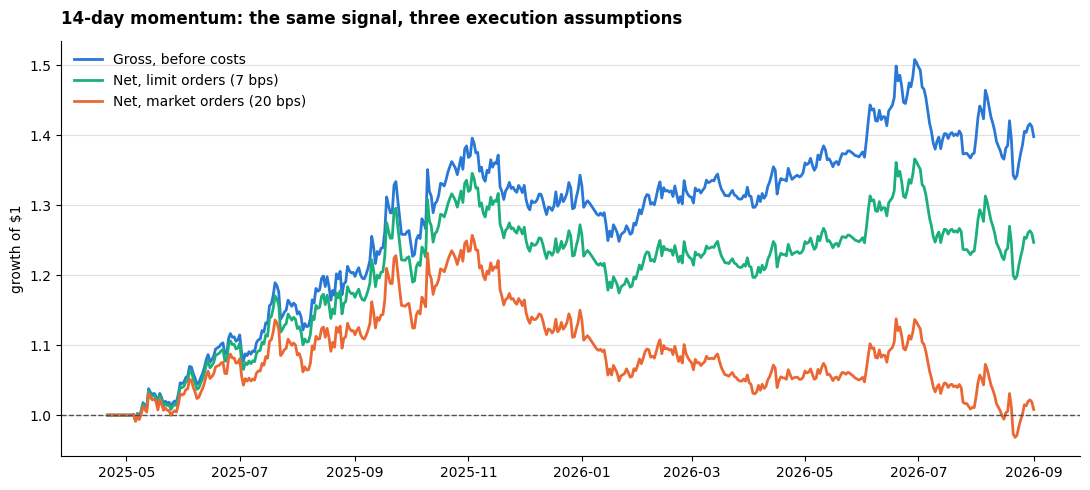

In [29]:
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

bt20 = backtest(momentum_signals[14], returns, cost_bps=20)
bt07 = backtest(momentum_signals[14], returns, cost_bps=7)

fig, ax = plt.subplots(figsize=(11, 5))
for series, colour, label in (
        (bt20.gross, BLUE,   "Gross, before costs"),
        (bt07.net,   AQUA,   "Net, limit orders (7 bps)"),
        (bt20.net,   ORANGE, "Net, market orders (20 bps)")):
    ax.plot(series.index, (1 + series).cumprod(), lw=2, color=colour, label=label)

# $1 line: anything below it is losing money.
ax.axhline(1.0, color="#52514e", lw=1, ls="--")

ax.set_title("14-day momentum: the same signal, three execution assumptions",
             loc="left", fontweight="bold", pad=12)
ax.set_ylabel("growth of $1")
ax.grid(True, axis="y", alpha=0.4)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
